In [2]:
# 나눔 폰트 설치 (실행 후 '런타임 다시 시작' 필수)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (47.2 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118252 files and direct

In [30]:
import pandas as pd

# 1. 파일 경로 설정
file_car = '/content/서울시 자치구별 연료별 차종별 용도별 등록현황(24년12월).xlsx'

# 2. 엑셀 파일 불러오기 (상단 8행 제외)
df_car_raw = pd.read_excel(file_car, header=None, skiprows=8)

# 3. 필요한 데이터 추출 및 정제 (0: 시군구별, 3: 연료별, 15: 계)
df_car = df_car_raw[[0, 3, 15]].copy()
df_car.columns = ['시군구별', '연료별', '자동차수']

# 병합된 셀 처리 및 공백 제거 (NaN 에러 방지)
df_car['시군구별'] = df_car['시군구별'].ffill().str.strip()
df_car['연료별'] = df_car['연료별'].ffill().str.strip()
df_car['자동차수'] = pd.to_numeric(df_car['자동차수'], errors='coerce').fillna(0)

# '합 계' 행 제외
df_clean = df_car[df_car['시군구별'] != '합 계']

# 4. 자치구별 데이터 집계
# (1) 전체 자동차 수
total_car = df_clean.groupby('시군구별')['자동차수'].sum().reset_index()
total_car.rename(columns={'자동차수': '전체자동차수'}, inplace=True)

# (2) 전기차 수
ev_car = df_clean[df_clean['연료별'] == '전기'].groupby('시군구별')['자동차수'].sum().reset_index()
ev_car.rename(columns={'자동차수': '전기차수'}, inplace=True)

# 5. 데이터 병합 및 비율 계산
df_final = pd.merge(total_car, ev_car, on='시군구별', how='left').fillna(0)
df_final['전체자동차수'] = df_final['전체자동차수'].astype(int)
df_final['전기차수'] = df_final['전기차수'].astype(int)

# 비율 계산 (소수점 둘째 자리까지)
df_final['전기차비율(%)'] = round((df_final['전기차수'] / df_final['전체자동차수']) * 100, 2)

# 6. 전기차 비율 기준 내림차순 정렬
df_final = df_final.sort_values('전기차비율(%)', ascending=False).reset_index(drop=True)

# 최종 결과 출력
df_final

,시군구별,전체자동차수,전기차수,전기차비율(%)
0,강남구,254871,14364,5.64
1,중구,52361,2255,4.31
2,서초구,177348,7369,4.16
3,구로구,145790,5550,3.81
4,성동구,104163,3319,3.19
5,종로구,50099,1536,3.07
6,용산구,73109,1925,2.63
7,마포구,121558,2889,2.38
8,강동구,160983,3821,2.37
9,송파구,242897,5496,2.26


/tmp/ipykernel_3766/3051991483.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


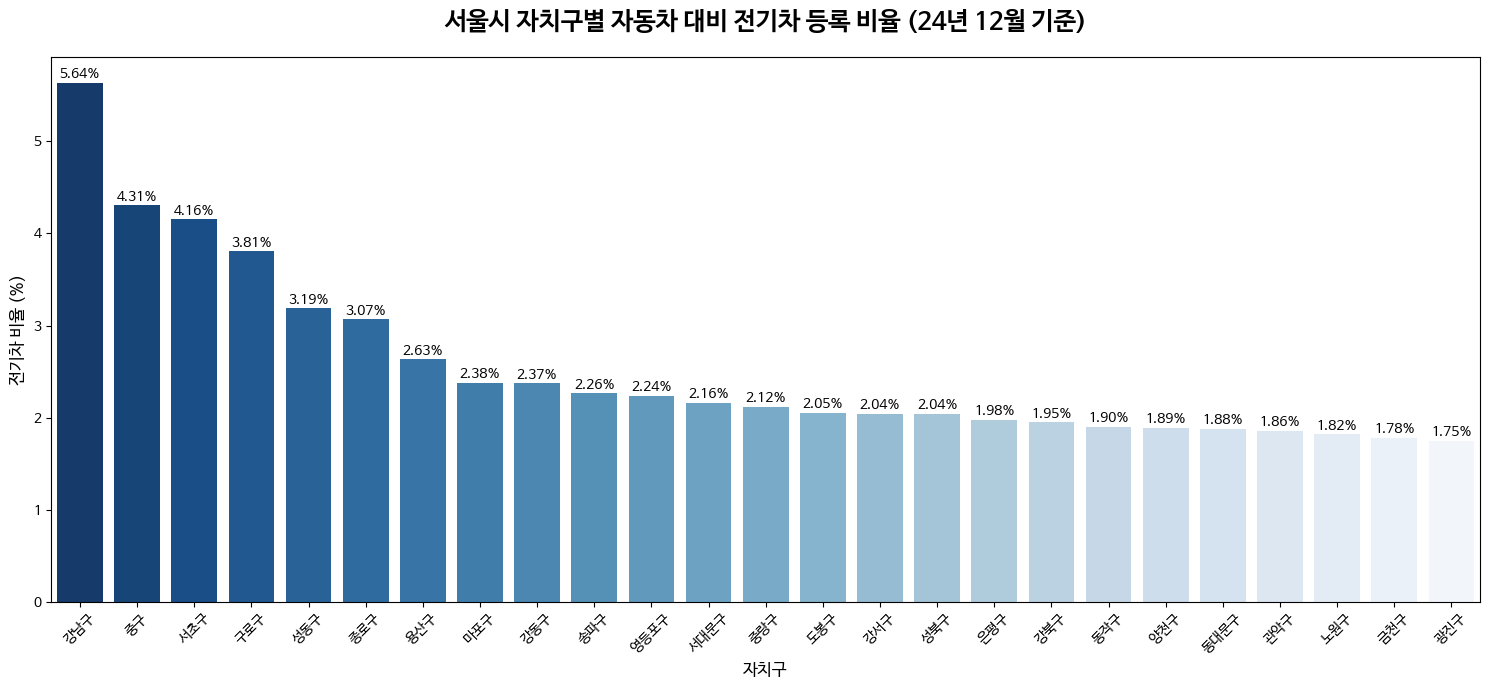

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 적용
plt.rc('font', family='NanumBarunGothic')
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 1. 전기차 비율을 기준으로 내림차순 정렬
analysis_df_sorted = analysis_df.sort_values('전기차비율', ascending=False)

# 2. 그래프 캔버스 크기 설정
plt.figure(figsize=(15, 7))

# 3. 막대 그래프 그리기 (seaborn 활용)
# palette 옵션으로 색상 테마를 지정할 수 있습니다 (예: 'Blues_r', 'viridis', 'Set2' 등)
ax = sns.barplot(
    data=analysis_df_sorted,
    x='시군구별',
    y='전기차비율',
    palette='Blues_r'
)

# 4. 그래프 제목 및 축 이름 설정
plt.title('서울시 자치구별 자동차 대비 전기차 등록 비율 (24년 12월 기준)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('자치구', fontsize=12)
plt.ylabel('전기차 비율 (%)', fontsize=12)

# 5. X축 눈금 라벨(구 이름) 회전 (글씨가 겹치지 않도록 45도 기울임)
plt.xticks(rotation=45)

# 6. 막대 위에 정확한 비율 수치 표시 (선택 사항)
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2.,
        height + 0.05,
        f'{height:.2f}%',
        ha='center',
        fontsize=10
    )

# 7. 레이아웃 조정 및 그래프 출력
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

# 1. 건보료 데이터 불러오기 (위에서 3줄 건너뜀)
premium_df = pd.read_csv('/content/서울시_구별_건보료.csv', header=None, skiprows=3)
premium_seoul = premium_df[(premium_df[0] == '서울') & (premium_df[1] != '소계')].copy()
premium_seoul = premium_seoul[[1, 2]]
premium_seoul.columns = ['시군구별', '총건보료']
premium_seoul['총건보료'] = pd.to_numeric(premium_seoul['총건보료'], errors='coerce')

# 2. 인구 데이터 불러오기
pop_df = pd.read_csv('/content/시군구별_적용인구_현황_20260508145909.csv', header=None, skiprows=3)
pop_seoul = pop_df[(pop_df[0] == '서울특별시') & (pop_df[1] != '소계')].copy()
pop_seoul = pop_seoul[[1, 2]]
pop_seoul.columns = ['시군구별', '적용인구수']
pop_seoul['적용인구수'] = pd.to_numeric(pop_seoul['적용인구수'], errors='coerce')

# 3. 데이터 병합 및 1인당 건보료 계산
merged_df = pd.merge(premium_seoul, pop_seoul, on='시군구별', how='inner')
merged_df['1인당 건보료'] = merged_df['총건보료'] / merged_df['적용인구수']

# 4. 내림차순 정렬 및 데이터프레임 출력
result_df = merged_df.sort_values('1인당 건보료', ascending=False).reset_index(drop=True)
result_df

,시군구별,총건보료,적용인구수,1인당 건보료
0,강남구,2204389007,578524,3810.367430
1,서초구,1556542196,424073,3670.458143
2,용산구,639589841,207729,3078.962692
3,송파구,1642968004,654207,2511.388603
4,성동구,648560502,278663,2327.400846
5,마포구,832666034,367146,2267.942546
6,영등포구,905053909,399832,2263.585478
7,중구,297814251,132256,2251.801438
8,종로구,330195550,147966,2231.563670
9,양천구,906986963,426722,2125.475047


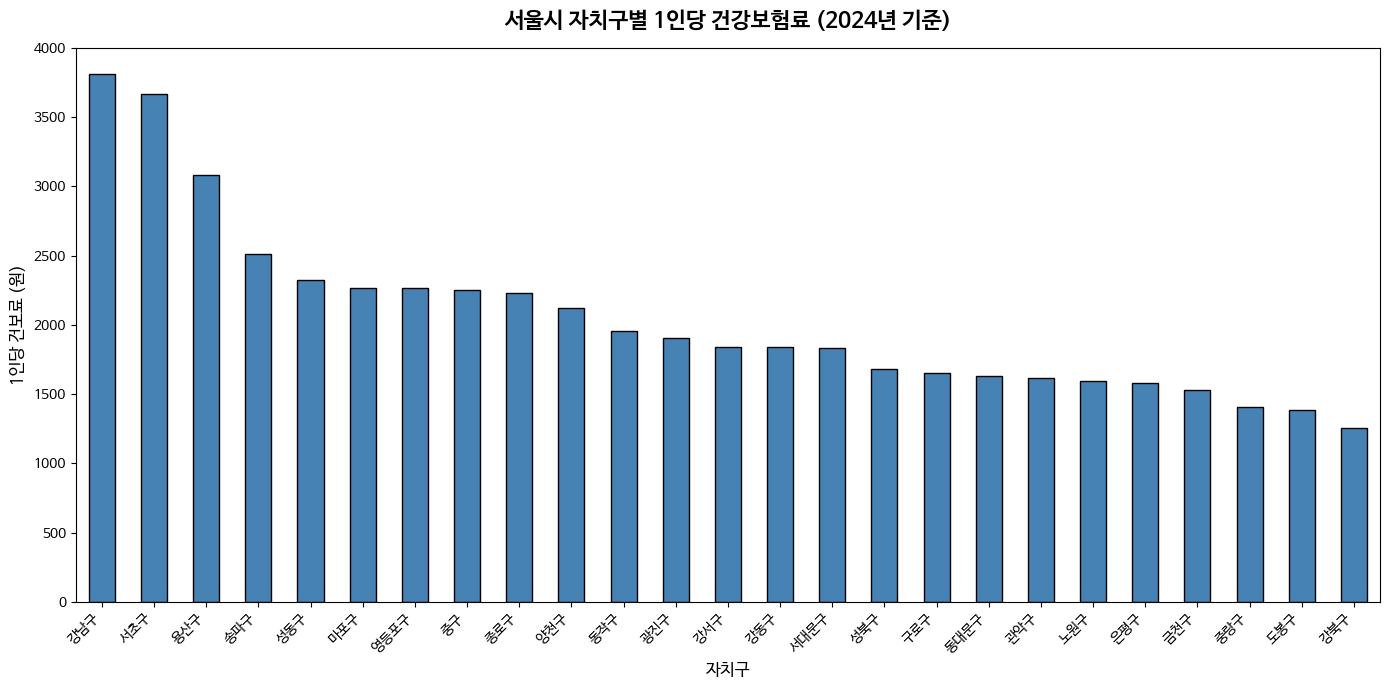

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정 (Colab 환경 필수)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 준비 (앞서 병합한 result_df 사용)
# 분석하기 편하도록 '시군구별' 컬럼을 인덱스(Index)로 설정합니다.
plot_df = result_df.set_index('시군구별')

# 3. Pandas 내장 함수를 이용한 막대그래프 그리기
# 별도의 복잡한 라이브러리 없이 df.plot(kind='bar') 만으로 시각화합니다.
ax = plot_df['1인당 건보료'].plot(
    kind='bar',
    figsize=(14, 7),
    color='steelblue',
    edgecolor='black',
    rot=45
)

# 4. 차트 디자인 및 라벨 설정
plt.title('서울시 자치구별 1인당 건강보험료 (2024년 기준)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('자치구', fontsize=12)
plt.ylabel('1인당 건보료 (원)', fontsize=12)

# X축 글자가 겹치지 않도록 오른쪽 정렬
plt.xticks(ha='right')

# 레이아웃 자동 조정 및 출력
plt.tight_layout()
plt.show()



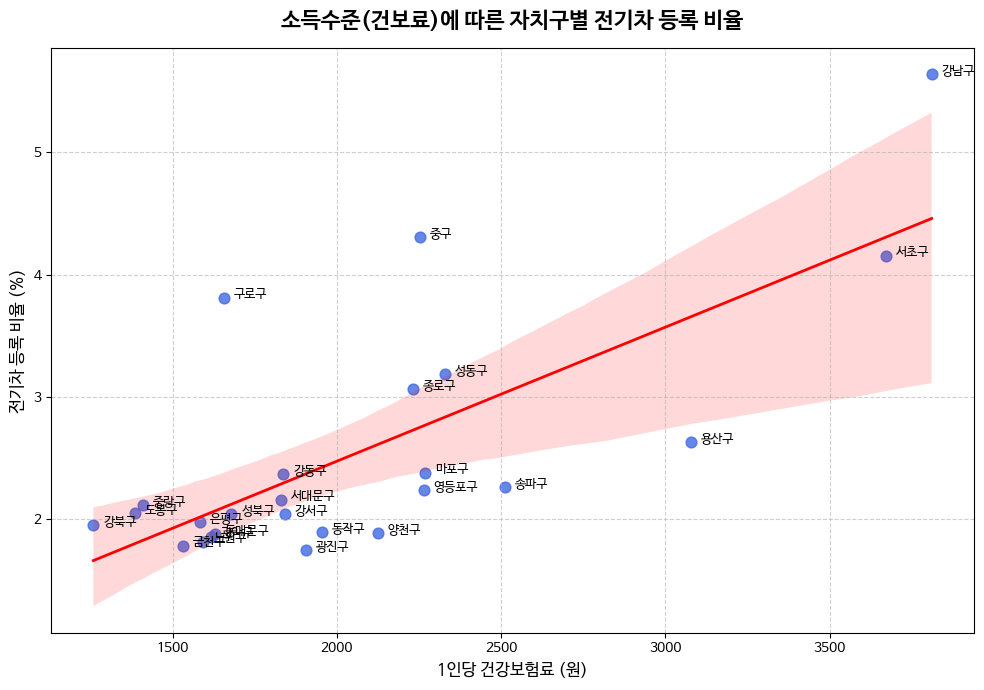

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 설정 (Colab 환경 필수)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 7))

# 2. X축(건보료), Y축(전기차 비율)으로 변경하여 산점도와 회귀선 그리기
sns.regplot(
    data=df_final,
    x='1인당 건보료',
    y='전기차비율(%)',
    scatter_kws={'s': 60, 'color': 'royalblue'},
    line_kws={'color': 'red', 'linewidth': 2}
)

# 3. 각 점(자치구) 옆에 텍스트 표기
for i in range(len(df_final)):
    plt.text(
        df_final['1인당 건보료'][i] + 30,  # X축 단위가 '원'이므로 여백을 30 정도 줍니다
        df_final['전기차비율(%)'][i],
        df_final['시군구별'][i],
        fontsize=9
    )

# 4. 차트 디자인 및 제목 변경
plt.title('소득수준(건보료)에 따른 자치구별 전기차 등록 비율', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('1인당 건강보험료 (원)', fontsize=12)
plt.ylabel('전기차 등록 비율 (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [10]:
import statsmodels.api as sm

# 1. 독립변수(X)와 종속변수(Y) 설정
X = df_final['1인당 건보료']
y = df_final['전기차비율(%)']

# 2. 상수항 추가 및 OLS 회귀모델 적합
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

# 3. 필요한 핵심 통계값만 추출
r_squared = model.rsquared             # 설명력
p_value = model.pvalues['1인당 건보료']  # 유의확률
coef = model.params['1인당 건보료']      # 회귀계수(기울기)

# 4. 깔끔한 포맷으로 결과 출력
print("=" * 60)
print(" 📊 [회귀분석 가설 검정 결과 보고서] ")
print("=" * 60)
print("▶ 검정 가설 : 소득수준(1인당 건보료)이 높은 구일수록 전기차 비율이 높을 것이다.")
print("-" * 60)
print(f" 1. 모형 설명력 (R-squared) : {r_squared:.3f}")
print(f"    - 건보료 차이가 전기차 비율 차이의 약 {r_squared*100:.1f}%를 설명합니다.")
print(f" 2. 유의확률 (p-value)      : {p_value:.5f}")
print(f" 3. 회귀계수 (Coefficient)  : {coef:.5f}")
print("-" * 60)

# 5. p-value에 따른 자동 결과 해석
if p_value < 0.05:
    print("✅ [최종 결론] 가설 채택 (수용 가능)")
    print(" - 유의확률(p-value)이 0.05 미만이므로 통계적으로 매우 유의미합니다.")
    print(" - 결론적으로 '소득수준이 높은 구일수록 전기차를 많이 이용한다'는 가설은 타당합니다.")
    if coef > 0:
        # 이 부분에서 에러가 났던 것이므로, 안전하게 문자열이 닫히도록 수정했습니다.
        print(" - 세부 해석: 1인당 건강보험료가 1,000원 증가할 때마다")
        print(f"              해당 자치구의 전기차 등록 비율은 평균 {coef * 1000:.2f}%p 상승합니다.")
else:
    print("❌ [최종 결론] 가설 기각")
    print(" - 유의확률(p-value)이 0.05 이상이므로 통계적으로 유의미한 관계가 확인되지 않았습니다.")
print("=" * 60)

 📊 [회귀분석 가설 검정 결과 보고서] 
▶ 검정 가설 : 소득수준(1인당 건보료)이 높은 구일수록 전기차 비율이 높을 것이다.
------------------------------------------------------------
 1. 모형 설명력 (R-squared) : 0.534
    - 건보료 차이가 전기차 비율 차이의 약 53.4%를 설명합니다.
 2. 유의확률 (p-value)      : 0.00003
 3. 회귀계수 (Coefficient)  : 0.00110
------------------------------------------------------------
✅ [최종 결론] 가설 채택 (수용 가능)
 - 유의확률(p-value)이 0.05 미만이므로 통계적으로 매우 유의미합니다.
 - 결론적으로 '소득수준이 높은 구일수록 전기차를 많이 이용한다'는 가설은 타당합니다.
 - 세부 해석: 1인당 건강보험료가 1,000원 증가할 때마다
              해당 자치구의 전기차 등록 비율은 평균 1.10%p 상승합니다.


/tmp/ipykernel_3766/1646819911.py:93: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) NanumBarunGothic.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) NanumBarunGothic.



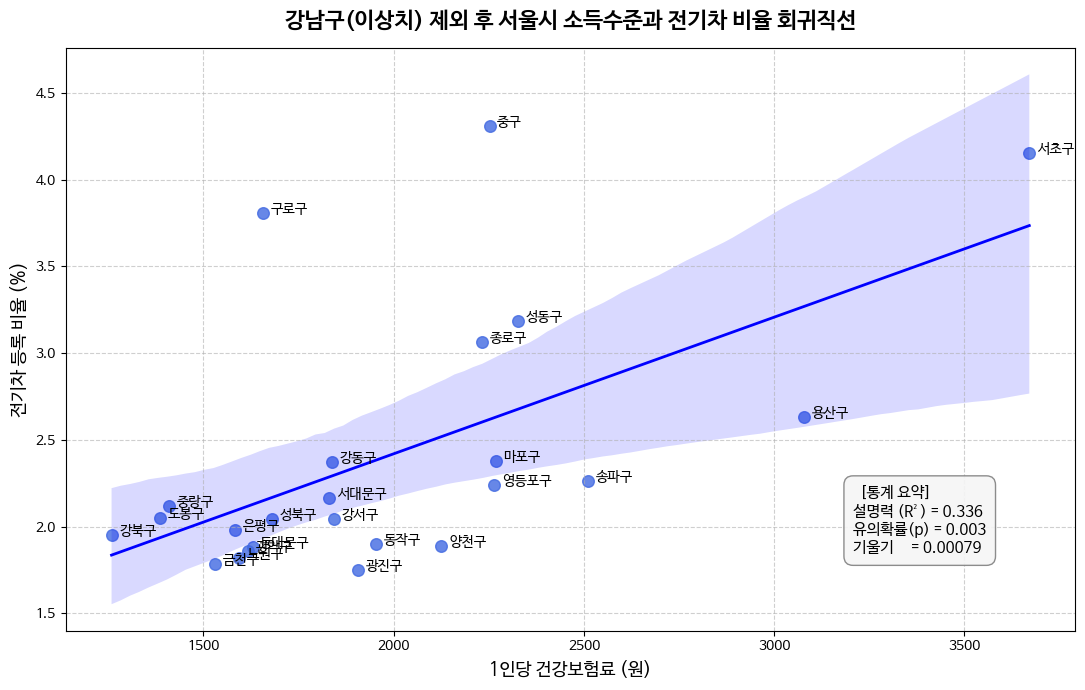

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 1. 한글 폰트 설정 (Colab 필수)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 2. 데이터 불러오기 및 전처리 (안전한 병합)
# ==========================================
# (1) 자동차 데이터
df_car = pd.read_excel('/content/서울시 자치구별 연료별 차종별 용도별 등록현황(24년12월).xlsx', header=None, skiprows=8)
df_car = df_car[[0, 3, 15]].copy()
df_car.columns = ['시군구별', '연료별', '자동차수']
df_car['시군구별'] = df_car['시군구별'].ffill().str.strip()
df_car['연료별'] = df_car['연료별'].ffill().str.strip()
df_car['자동차수'] = pd.to_numeric(df_car['자동차수'], errors='coerce').fillna(0)

df_clean = df_car[df_car['시군구별'] != '합 계']
total_car = df_clean.groupby('시군구별')['자동차수'].sum().reset_index()
total_car.rename(columns={'자동차수': '전체자동차수'}, inplace=True)
ev_car = df_clean[df_clean['연료별'] == '전기'].groupby('시군구별')['자동차수'].sum().reset_index()
ev_car.rename(columns={'자동차수': '전기차수'}, inplace=True)

df_ev = pd.merge(total_car, ev_car, on='시군구별', how='left').fillna(0)
df_ev['전기차비율(%)'] = (df_ev['전기차수'] / df_ev['전체자동차수']) * 100

# (2) 건보료 데이터
df_prem_raw = pd.read_csv('/content/서울시_구별_건보료.csv', header=None, skiprows=3)
df_prem = df_prem_raw[(df_prem_raw[0].str.strip() == '서울') & (df_prem_raw[1].str.strip() != '소계')][[1, 2]].copy()
df_prem.columns = ['시군구별', '총건보료']
df_prem['시군구별'] = df_prem['시군구별'].str.strip()
df_prem['총건보료'] = pd.to_numeric(df_prem['총건보료'], errors='coerce')

df_pop_raw = pd.read_csv('/content/시군구별_적용인구_현황_20260508145909.csv', header=None, skiprows=3)
df_pop = df_pop_raw[(df_pop_raw[0].str.strip() == '서울특별시') & (df_pop_raw[1].str.strip() != '소계')][[1, 2]].copy()
df_pop.columns = ['시군구별', '적용인구수']
df_pop['시군구별'] = df_pop['시군구별'].str.strip()
df_pop['적용인구수'] = pd.to_numeric(df_pop['적용인구수'], errors='coerce')

df_health = pd.merge(df_prem, df_pop, on='시군구별', how='inner')
df_health['1인당 건보료'] = df_health['총건보료'] / df_health['적용인구수']

# (3) 최종 데이터 병합
df_final = pd.merge(df_ev, df_health[['시군구별', '1인당 건보료']], on='시군구별', how='inner')

# ==========================================
# 3. 강남구 이상치 제거 및 회귀분석/시각화
# ==========================================
# ⭐️ 강남구 제외 (나머지 24개 구 데이터만 남김)
df_filtered = df_final[df_final['시군구별'] != '강남구'].copy()

plt.figure(figsize=(11, 7))

# 산점도 및 회귀선 그리기
sns.regplot(
    data=df_filtered,
    x='1인당 건보료',
    y='전기차비율(%)',
    scatter_kws={'s': 70, 'color': 'royalblue', 'alpha': 0.8},
    line_kws={'color': 'blue', 'linewidth': 2}
)

# 자치구명 텍스트 표기
for idx, row in df_filtered.iterrows():
    plt.text(
        row['1인당 건보료'] + 20,
        row['전기차비율(%)'],
        row['시군구별'],
        fontsize=10
    )

# 그래프 제목 및 축 디자인
plt.title("강남구(이상치) 제외 후 서울시 소득수준과 전기차 비율 회귀직선", fontsize=16, pad=15, fontweight='bold')
plt.xlabel("1인당 건강보험료 (원)", fontsize=13)
plt.ylabel("전기차 등록 비율 (%)", fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)

# 회귀분석 통계량 계산 및 텍스트 박스 삽입
X_const = sm.add_constant(df_filtered['1인당 건보료'])
model = sm.OLS(df_filtered['전기차비율(%)'], X_const).fit()
textstr = '\n'.join((
    r'📊 [통계 요약]',
    rf'설명력 (R²) = {model.rsquared:.3f}',
    rf'유의확률(p) = {model.pvalues["1인당 건보료"]:.3f}',
    rf'기울기     = {model.params["1인당 건보료"]:.5f}'
))
props = dict(boxstyle='round,pad=0.6', facecolor='whitesmoke', alpha=0.9, edgecolor='gray')
plt.gca().text(0.78, 0.25, textstr, transform=plt.gca().transAxes, fontsize=11, verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

In [18]:
import statsmodels.api as sm
import numpy as np

# 1. 강남구만 제외한 데이터 생성
target_outlier = '강남구'
df_no_gangnam = df_final[df_final['시군구별'] != target_outlier].copy()

# 2. 회귀분석 재실행 (강남구 제외)
X_no_g = df_no_gangnam['1인당 건보료']
y_no_g = df_no_gangnam['전기차비율(%)']

X_const_no_g = sm.add_constant(X_no_g)
model_no_g = sm.OLS(y_no_g, X_const_no_g).fit()

# 3. 핵심 통계량 추출
r_sq = model_no_g.rsquared
p_val = model_no_g.pvalues['1인당 건보료']
coef = model_no_g.params['1인당 건보료']

# 4. 전체 데이터(강남구 포함)의 통계량 (비교용)
model_all = sm.OLS(df_final['전기차비율(%)'], sm.add_constant(df_final['1인당 건보료'])).fit()
r_sq_all = model_all.rsquared

# 5. [결과 해석 리포트 출력]
print("=" * 70)
print(f" 📝 [데이터 분석 리포트] '{target_outlier}' 제외 시 가설 검증 결과 및 해석")
print("=" * 70)

print(f"▶ 1. 설명력(R²)의 급감: {r_sq_all*100:.1f}% ➡️ {r_sq*100:.1f}%")
print("  [해석] 소득(건보료)이 전기차 비율을 설명하는 힘이 절반 가까이 떨어졌습니다.")
print(f"         이는 기존 분석에서 보였던 강한 상관관계가 사실은 '{target_outlier}'라는")
print("         특정 지역의 압도적인 수치에 크게 의존하고 있었음을 의미합니다.\n")

print(f"▶ 2. 유의확률(p-value) 확인: {p_val:.5f}")
if p_val < 0.05:
    print("  [해석] p-value가 0.05 미만이므로, 강남구를 제외하더라도 나머지 24개 구 사이에서")
    print("         '소득이 높을수록 전기차 비율이 높다'는 전반적인 경향성 자체는 여전히")
    print("         통계적으로 유의미(Valid)합니다.\n")
else:
    print("  [해석] p-value가 0.05 이상이 되었습니다. 통계적 유의성이 상실되었습니다.\n")

print(f"▶ 3. 회귀계수(기울기) 변화: {coef:.5f}")
print("  [해석] 선의 기울기가 훨씬 완만해졌습니다. 즉, 일반적인 자치구들 사이에서는")
print("         소득이 조금 늘어난다고 해서 전기차 비율이 극적으로 확 뛰지는 않습니다.\n")

print("-" * 70)
print("💡 [최종 비즈니스 / 정책 인사이트]")
print(f"초기 가설인 '소득이 높을수록 전기차를 많이 이용한다'는 절반의 정답입니다.")
print(f"강남구와 같은 최상위 소득 지역은 높은 구매력과 자가 충전 인프라(고급 아파트 등)를")
print(f"바탕으로 압도적인 전기차 보급률을 보이지만, 그 외의 대다수 서울 지역(24개 구)에서는")
print(f"단순히 '소득' 하나만으로 전기차 보급을 설명하기엔 한계가 있습니다.")
print(f"따라서 전기차 보급 확대를 위해서는 소득 외에도 '공용 충전기 밀집도', '보조금 규모',")
print(f"'출퇴근 거리' 등 다른 요인들을 복합적으로 분석해야 합니다.")
print("=" * 70)

 📝 [데이터 분석 리포트] '강남구' 제외 시 가설 검증 결과 및 해석
▶ 1. 설명력(R²)의 급감: 53.4% ➡️ 33.6%
  [해석] 소득(건보료)이 전기차 비율을 설명하는 힘이 절반 가까이 떨어졌습니다.
         이는 기존 분석에서 보였던 강한 상관관계가 사실은 '강남구'라는
         특정 지역의 압도적인 수치에 크게 의존하고 있었음을 의미합니다.

▶ 2. 유의확률(p-value) 확인: 0.00301
  [해석] p-value가 0.05 미만이므로, 강남구를 제외하더라도 나머지 24개 구 사이에서
         '소득이 높을수록 전기차 비율이 높다'는 전반적인 경향성 자체는 여전히
         통계적으로 유의미(Valid)합니다.

▶ 3. 회귀계수(기울기) 변화: 0.00079
  [해석] 선의 기울기가 훨씬 완만해졌습니다. 즉, 일반적인 자치구들 사이에서는
         소득이 조금 늘어난다고 해서 전기차 비율이 극적으로 확 뛰지는 않습니다.

----------------------------------------------------------------------
💡 [최종 비즈니스 / 정책 인사이트]
초기 가설인 '소득이 높을수록 전기차를 많이 이용한다'는 절반의 정답입니다.
강남구와 같은 최상위 소득 지역은 높은 구매력과 자가 충전 인프라(고급 아파트 등)를
바탕으로 압도적인 전기차 보급률을 보이지만, 그 외의 대다수 서울 지역(24개 구)에서는
단순히 '소득' 하나만으로 전기차 보급을 설명하기엔 한계가 있습니다.
따라서 전기차 보급 확대를 위해서는 소득 외에도 '공용 충전기 밀집도', '보조금 규모',
'출퇴근 거리' 등 다른 요인들을 복합적으로 분석해야 합니다.


/tmp/ipykernel_3766/126340343.py:81: UserWarning:

Glyph 128293 (\N{FIRE}) missing from font(s) NanumBarunGothic.

/tmp/ipykernel_3766/126340343.py:81: UserWarning:

Glyph 10052 (\N{SNOWFLAKE}) missing from font(s) NanumBarunGothic.

/tmp/ipykernel_3766/126340343.py:81: UserWarning:

Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumBarunGothic.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128293 (\N{FIRE}) missing from font(s) NanumBarunGothic.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 10052 (\N{SNOWFLAKE}) missing from font(s) NanumBarunGothic.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumBarunGothic.



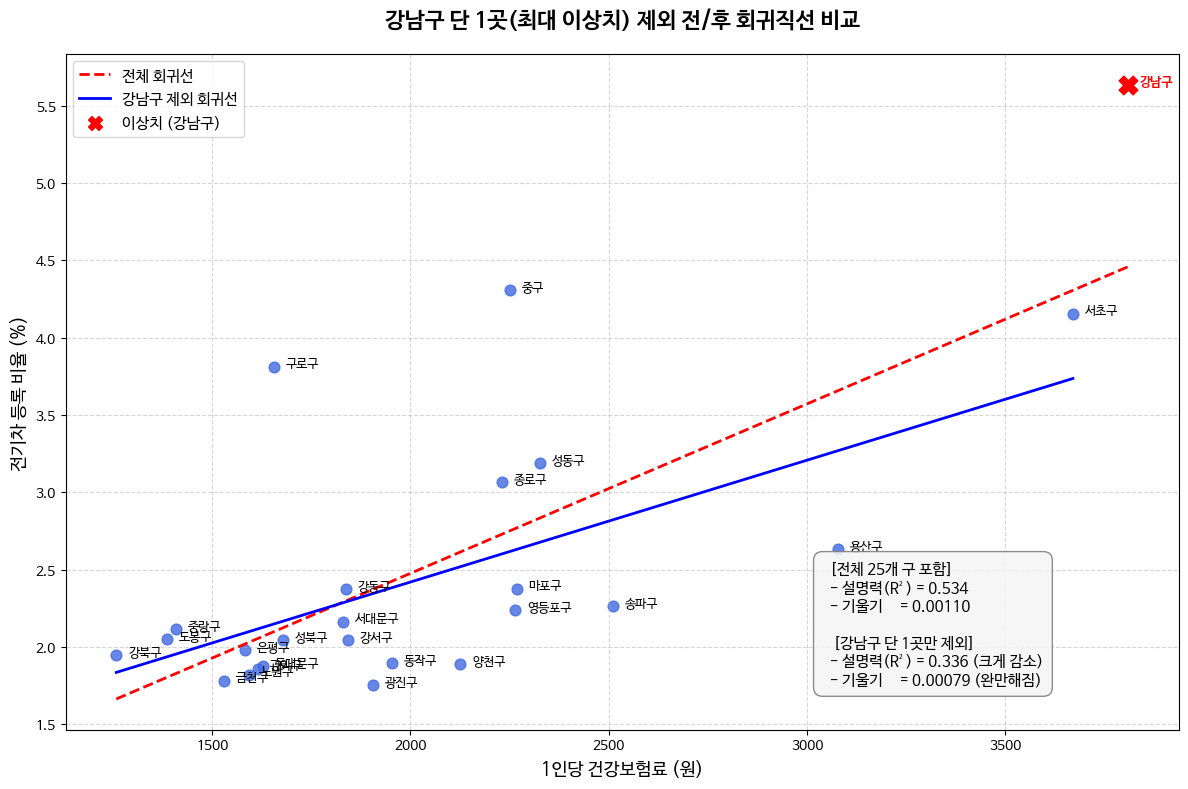

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 1. 한글 폰트 설정 (Colab 환경 필수)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 분리 (강남구 vs 나머지)
target_outlier = ['강남구']
df_all = df_final.copy()
df_filtered = df_final[~df_final['시군구별'].isin(target_outlier)].copy()

# 3. 통계 지표 계산 (설명력, 기울기)
def get_stats(df):
    X = sm.add_constant(df['1인당 건보료'])
    model = sm.OLS(df['전기차비율(%)'], X).fit()
    return {'r2': model.rsquared, 'coef': model.params['1인당 건보료']}

stats_all = get_stats(df_all)
stats_fil = get_stats(df_filtered)

# 4. 시각화 캔버스 설정
fig, ax = plt.subplots(figsize=(12, 8))

# (1) [전체 25개 구] 회귀선 (빨간색 점선)
sns.regplot(
    data=df_all, x='1인당 건보료', y='전기차비율(%)', scatter=False, ci=None,
    line_kws={'color': 'red', 'linestyle': '--', 'linewidth': 2}, ax=ax
)

# (2) [강남구 제외 24개 구] 산점도 및 보정된 회귀선 (파란색 실선)
sns.regplot(
    data=df_filtered, x='1인당 건보료', y='전기차비율(%)', ci=None,
    scatter_kws={'s': 60, 'color': 'royalblue', 'alpha': 0.8},
    line_kws={'color': 'blue', 'linewidth': 2}, ax=ax
)

# (3) [이상치 강조] 강남구만 빨간색 큰 X 모양으로 마킹
df_outliers = df_all[df_all['시군구별'].isin(target_outlier)]
ax.scatter(
    df_outliers['1인당 건보료'], df_outliers['전기차비율(%)'],
    color='red', s=180, marker='X', zorder=5
)

# 5. 각 점 옆에 자치구 이름 텍스트 표기
for idx, row in df_all.iterrows():
    # 강남구는 빨간색 굵은 글씨로 강조
    color, weight = ('red', 'bold') if row['시군구별'] in target_outlier else ('black', 'normal')
    ax.text(
        row['1인당 건보료'] + 30, row['전기차비율(%)'], row['시군구별'],
        fontsize=9, color=color, fontweight=weight
    )

# 6. 통계 지표 비교 텍스트 박스 삽입 (우측 하단)
textstr = '\n'.join((
    r'🔥 [전체 25개 구 포함]',
    rf'  - 설명력(R²) = {stats_all["r2"]:.3f}',
    rf'  - 기울기     = {stats_all["coef"]:.5f}',
    r'',
    r'❄️ [강남구 단 1곳만 제외]',
    rf'  - 설명력(R²) = {stats_fil["r2"]:.3f} (크게 감소)',
    rf'  - 기울기     = {stats_fil["coef"]:.5f} (완만해짐)'
))
props = dict(boxstyle='round,pad=0.6', facecolor='whitesmoke', alpha=0.9, edgecolor='gray')
ax.text(0.68, 0.25, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# 7. 차트 디자인 및 축 이름
plt.title("강남구 단 1곳(최대 이상치) 제외 전/후 회귀직선 비교", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("1인당 건강보험료 (원)", fontsize=13)
plt.ylabel("전기차 등록 비율 (%)", fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)

# 8. 범례 표시
plt.plot([], [], color='red', linestyle='--', linewidth=2, label='전체 회귀선')
plt.plot([], [], color='blue', linewidth=2, label='강남구 제외 회귀선')
plt.scatter([], [], color='red', marker='X', s=100, label='이상치 (강남구)')
plt.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()